# This is the pipeline for target prioritization.

In [7]:
# import the required packages
import os
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline
import requests

In [4]:
# Directories
DIR_TABLES = r"C:\Users\naemi\Documents\Cis-platin\Cisplatin-Resistant-Ovarian-Cancer-Drug-Discovery\Results\Tables"
DIR_FIGURES = r"C:\Users\naemi\Documents\Cis-platin\Cisplatin-Resistant-Ovarian-Cancer-Drug-Discovery\Results\Figures\plots"

os.makedirs(DIR_TABLES, exist_ok=True)
os.makedirs(DIR_FIGURES, exist_ok=True)

# Load the Data

In [5]:
# Load the candidate genes and existing deg, survival data for building up an evidence
FINAL_CANDIDATES = pd.read_csv(os.path.join(DIR_TABLES, "16_prognostic_genes.csv"))["gene"].tolist()
print(f"Loaded {len(FINAL_CANDIDATES)} final candidate gene(s): {FINAL_CANDIDATES}")

deg = pd.read_csv(os.path.join(DIR_TABLES, "11_DEGs_resistant_vs_sensitive.csv")).set_index("gene")
surv = pd.read_csv(os.path.join(DIR_TABLES, "15_survival_results.csv")).set_index("gene")

rows = []
for g in FINAL_CANDIDATES:
    row = {"gene": g}
    if g in deg.index:
        row["DEG_logFC"] = deg.loc[g, "logFC"]
        row["DEG_adj_p"] = deg.loc[g, "adj_p"]
    else:
        print(f"WARNING: {g} not found in DEG table — check gene symbol spelling/case")
    if g in surv.index:
        row["survival_HR"] = surv.loc[g, "HR"]
        row["survival_p"] = surv.loc[g, "logrank_p"]
    else:
        print(f"WARNING: {g} not found in survival table — check gene symbol spelling/case")
    rows.append(row)

internal = pd.DataFrame(rows).set_index("gene")
print("\nInternal evidence loaded:\n", internal)

Loaded 2 final candidate gene(s): ['DLX5', 'HCFC2']

Internal evidence loaded:
        DEG_logFC  DEG_adj_p  survival_HR  survival_p
gene                                                
DLX5   -2.288932   0.722349     1.401833    0.024447
HCFC2   0.886181   0.722349     1.362264    0.038780


# Checking for druggability

In [ ]:

# Structural druggability (Open Targets Platform)

def get_opentargets_tractability(gene_symbol):
    query = """
    query targetInfo($symbol: String!) {
      search(queryString: $symbol, entityNames: ["target"]) { hits { id name } }
    }"""
    r = requests.post("https://api.platform.opentargets.org/api/v4/graphql",
                       json={"query": query, "variables": {"symbol": gene_symbol}})
    hits = r.json().get("data", {}).get("search", {}).get("hits", [])
    if not hits:
        return {"gene": gene_symbol, "ensembl_id": None, "tractability_sm": []}
    ensembl_id = hits[0]["id"]

    detail_query = """
    query tractability($id: String!) {
      target(ensemblId: $id) { tractability { modality value label } }
    }"""
    r2 = requests.post("https://api.platform.opentargets.org/api/v4/graphql",
                        json={"query": detail_query, "variables": {"id": ensembl_id}})
    tract = r2.json().get("data", {}).get("target", {}).get("tractability", [])
    sm_hits = [t["label"] for t in tract if t.get("modality") == "SM" and t.get("value")]
    return {"gene": gene_symbol, "ensembl_id": ensembl_id, "tractability_sm": sm_hits}

SM_TIER_SCORE_NOVEL = {
    "High-Quality Pocket": 3.5, "Structure with Ligand": 5, "High-Quality Ligand": 4.5,
    "Med-Quality Pocket": 1.5, "Druggable Family": 1.5,
    "Phase 1 Clinical": 1.0, "Advanced Clinical": 0.75, "Approved Drug": 0.5,
}

druggability_rows = []
for g in FINAL_CANDIDATES:
    info = get_opentargets_tractability(g)
    tiers = info.get("tractability_sm") or []
    score = max([SM_TIER_SCORE_NOVEL.get(t, 0) for t in tiers] + [0])
    has_pocket = any(t in ["High-Quality Pocket", "Structure with Ligand", "Med-Quality Pocket"]
                      for t in tiers)
    druggability_rows.append({
        "gene": g, "ensembl_id": info.get("ensembl_id"),
        "druggability_score": score, "has_defined_pocket": has_pocket,
        "tractability_tiers": ", ".join(tiers) or "None found",
    })
    print(f"[{g}] Tractability tiers: {tiers} | pocket defined: {has_pocket}")

druggability_df = pd.DataFrame(druggability_rows).set_index("gene")


[DLX5] Tractability tiers: [] | pocket defined: False
[HCFC2] Tractability tiers: [] | pocket defined: False


# Essentiality
Checking: "If we genetically knock out this specific gene with CRISPR-Cas9, do the cancer cells stop proliferating and die?"

In [ ]:

# Essentiality using DepMap derived CRISPR score data

depmap_path =r"C:\Users\naemi\Documents\Cis-platin\Cisplatin-Resistant-Ovarian-Cancer-Drug-Discovery\Data\Raw\CRISPRGeneEffect.csv"

if os.path.exists(depmap_path):
    depmap = pd.read_csv(depmap_path, index_col=0)
    essentiality_rows = []
    for g in FINAL_CANDIDATES:
        matching_cols = [c for c in depmap.columns if c.split(" ")[0] == g]
        mean_score = depmap[matching_cols[0]].mean() if matching_cols else np.nan
        essentiality_rows.append({"gene": g, "mean_dependency_score": mean_score})
    essentiality_df = pd.DataFrame(essentiality_rows).set_index("gene")
    print("\nDepMap essentiality loaded (more negative = more essential):")
    print(essentiality_df)
else:
    print("\nNo DepMap file found — download CRISPRGeneEffect.csv from "
          "https://depmap.org/portal/download/ for causal validation before "
          "committing to novel compound design. Proceeding without it for now "
          "(this criterion will be scored neutrally for all genes).")
    essentiality_df = pd.DataFrame({"gene": FINAL_CANDIDATES,
                                     "mean_dependency_score": [np.nan] * len(FINAL_CANDIDATES)}
                                    ).set_index("gene")



DepMap essentiality loaded (more negative = more essential):
       mean_dependency_score
gene                        
DLX5               -0.110397
HCFC2               0.125965


# Expression specificity

This step queries HPA to verify whether the gene is selectively enriched in cancer cohorts rather than normal human physiology.

In [ ]:

#  Expression specificity from Human Protein Atlas

def get_hpa_specificity(gene_symbol):
    r = requests.get("https://www.proteinatlas.org/api/search_download.php",
                      params={"search": gene_symbol, "format": "json",
                              "columns": "g,rnacas", "compress": "no"})
    try:
        data = r.json()
        if not data:
            return {"gene": gene_symbol, "rna_specificity": None}
        return {"gene": gene_symbol, "rna_specificity": data[0].get("RNA cancer specificity")}
    except Exception as e:
        print(f"[{gene_symbol}] HPA query failed: {e}")
        return {"gene": gene_symbol, "rna_specificity": None}

SPECIFICITY_SCORE = {"Cancer enhanced": 3, "Group enhanced": 2, "Low cancer specificity": 1}
specificity_rows = []
for g in FINAL_CANDIDATES:
    info = get_hpa_specificity(g)
    score = SPECIFICITY_SCORE.get(info.get("rna_specificity"), 0)
    specificity_rows.append({"gene": g, "specificity_label": info.get("rna_specificity"),
                              "specificity_score": score})
    print(f"[{g}] HPA cancer specificity: {info.get('rna_specificity')}")

specificity_df = pd.DataFrame(specificity_rows).set_index("gene")

[DLX5] HPA cancer specificity: Cancer enriched
[HCFC2] HPA cancer specificity: Low cancer specificity


# Existing drug landscape

This step queries DGIdb to verify whether the gene is known to be a drug target and also how many drugs are known to target it.

In [ ]:

# Existing drug landscape

def get_dgidb_drugs(gene_symbol):
    r = requests.get("https://dgidb.org/api/graphql",
                      params={"query": f"""{{
                          genes(names: ["{gene_symbol}"]) {{
                              nodes {{ interactions {{ drug {{ name }} }} }}
                          }}
                      }}"""})
    try:
        nodes = r.json()["data"]["genes"]["nodes"]
        drugs = set()
        for n in nodes:
            for i in n["interactions"]:
                drugs.add(i["drug"]["name"])
        return sorted(drugs)
    except Exception as e:
        print(f"[{gene_symbol}] DGIdb query failed: {e}")
        return []

drug_rows = []
for g in FINAL_CANDIDATES:
    drugs = get_dgidb_drugs(g)
    drug_rows.append({"gene": g, "n_known_drugs": len(drugs)})
    print(f"[{g}] Existing drugs (context only — fewer = more open IP space): {len(drugs)}")

drug_df = pd.DataFrame(drug_rows).set_index("gene")

[DLX5] DGIdb query failed: Expecting value: line 1 column 1 (char 0)
[DLX5] Existing drugs (context only — fewer = more open IP space): 0
[HCFC2] DGIdb query failed: Expecting value: line 1 column 1 (char 0)
[HCFC2] Existing drugs (context only — fewer = more open IP space): 0


# Weighted composite scoring

This step scores the genes based on their overall druggability, essentiality, expression specificity, and survival significance.

In [ ]:

# Weighted composite scoring

WEIGHTS = {
    "druggability_score": 0.40,
    "essentiality": 0.35,
    "specificity_score": 0.15,
    "survival_significance": 0.10,
}

scorecard = internal.join(druggability_df).join(essentiality_df).join(specificity_df).join(drug_df)
scorecard["survival_significance"] = -np.log10(scorecard["survival_p"].clip(lower=1e-10))
scorecard["essentiality_score"] = -scorecard["mean_dependency_score"].fillna(0)

def normalize(col):
    if col.isna().all() or col.max() == col.min():
        return col.fillna(0) * 0 + 0.5   # neutral score if no variation/no data
    return (col - col.min()) / (col.max() - col.min())

norm_cols = {}
for raw_col, weight_key in [
    ("druggability_score", "druggability_score"),
    ("essentiality_score", "essentiality"),
    ("specificity_score", "specificity_score"),
    ("survival_significance", "survival_significance"),
]:
    if raw_col in scorecard.columns:
        norm_cols[weight_key] = normalize(scorecard[raw_col])


active_weights = {k: WEIGHTS[k] for k in norm_cols if k in WEIGHTS}
weight_sum = sum(active_weights.values())
active_weights = {k: v / weight_sum for k, v in active_weights.items()}

composite = sum(norm_cols[k] * active_weights[k] for k in norm_cols if k in active_weights)
scorecard["composite_score"] = composite
scorecard = scorecard.sort_values("composite_score", ascending=False)

scorecard.to_csv(os.path.join(DIR_TABLES, "17_final_target_scorecard.csv"))

print("\n" + "=" * 60)
print("FINAL SCORECARD")
print("=" * 60)
display_cols = [c for c in ["composite_score", "druggability_score", "has_defined_pocket",
                             "mean_dependency_score", "specificity_label", "survival_p",
                             "n_known_drugs"] if c in scorecard.columns]
print(scorecard[display_cols].to_string())

winner = scorecard.index[0]
runner_up = scorecard.index[1] if len(scorecard) > 1 else None
print(f"\n>>> RECOMMENDED FINAL TARGET: {winner} "
      f"(composite score {scorecard.loc[winner, 'composite_score']:.3f})")
if runner_up:
    margin = scorecard.loc[winner, "composite_score"] - scorecard.loc[runner_up, "composite_score"]
    print(f">>> Margin over {runner_up}: {margin:.3f} "
          f"({'clear winner' if margin > 0.15 else 'CLOSE — inspect the radar chart carefully'})")



FINAL SCORECARD
       composite_score  druggability_score  has_defined_pocket  mean_dependency_score       specificity_label  survival_p  n_known_drugs
gene                                                                                                                                    
DLX5              0.65                   0               False              -0.110397         Cancer enriched    0.024447              0
HCFC2             0.35                   0               False               0.125965  Low cancer specificity    0.038780              0

>>> RECOMMENDED FINAL TARGET: DLX5 (composite score 0.650)
>>> Margin over HCFC2: 0.300 (clear winner)


# Visualize

This step visualizes the radar chart and composite bar chart.

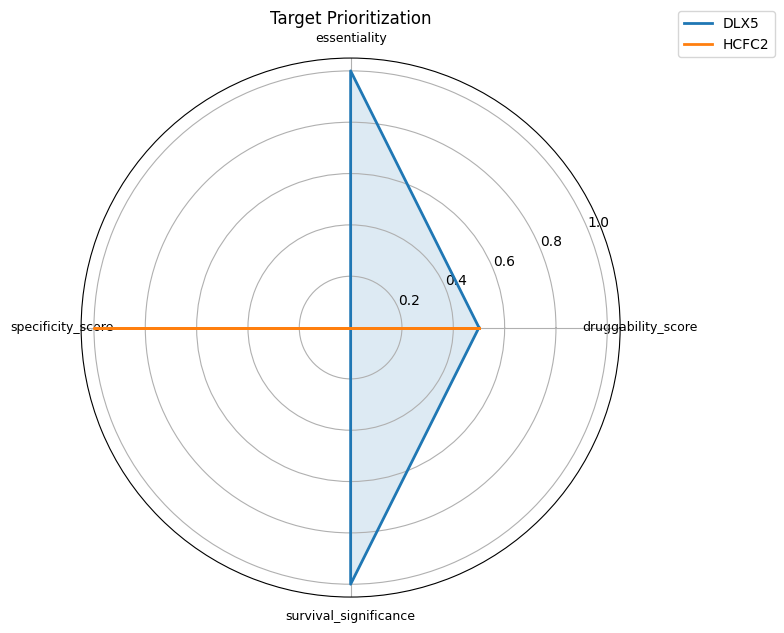

In [18]:

# Visualize the radar chart and composite bar chart

categories = list(norm_cols.keys())
angles = np.linspace(0, 2 * np.pi, len(categories), endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
for gene in scorecard.index:
    values = [norm_cols[c].loc[gene] for c in categories]
    values += values[:1]
    ax.plot(angles, values, linewidth=2, label=gene)
    ax.fill(angles, values, alpha=0.15)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=9)
ax.set_title("Target Prioritization")
ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))
plt.savefig(os.path.join(DIR_FIGURES, "09_target_radar_comparison.png"), dpi=1000)
plt.show()



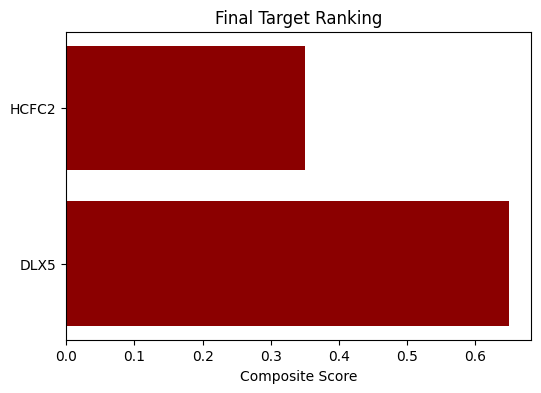

In [19]:
plt.figure(figsize=(6, 4))
plt.barh(scorecard.index, scorecard["composite_score"], color="darkred")
plt.xlabel("Composite Score")
plt.title("Final Target Ranking")
plt.savefig(os.path.join(DIR_FIGURES, "10_target_composite_score_bar.png"), dpi=1000)
plt.show()